In [1]:
library(Seurat)
library(dplyr)
library(tidyr)
library(ggplot2)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [2]:
name <- "vaccine"
dataset <- readRDS(paste0("../../results/sample_qc/",name, "/dataset_usable_sample_celltype_pairs.rds"))
meta <- dataset@meta.data

In [3]:
head(meta$lineage)

[1] "Monocytes"   "CD4 T cells" "CD8 T cells" "NK cells"    "CD8 T cells"
[6] "CD8 T cells"

In [4]:
OUT_DIR <- paste0("../../results/sample_qc/", name)
colnames(meta)

[1] "orig.ident"          "nCount_RNA"          "nFeature_RNA"       
 [4] "nCount_ADT"          "nFeature_ADT"        "lane"               
 [7] "donor"               "time"                "celltype.l1"        
[10] "celltype.l2"         "celltype.l3"         "Phase"              
[13] "Batch"               "sample"              "percent.mt"         
[16] "percent.ribo"        "percent.hb"          "mt_outlier_all"     
[19] "is_outlier_RNA"      "is_outlier_protein"  "is_outlier"         
[22] "RNA_snn_res.0.8"     "seurat_clusters"     "RNA_snn_res.0.25"   
[25] "RNA.weight"          "ADT.weight"          "leiden_0.8_totalVI" 
[28] "leiden_0.25_totalVI" "lineage"             "pla_status"         
[31] "celltype_clean"

In [5]:
strip_duplicate_suffix <- function(x) {
  # Remove Seurat-style duplicate suffixes such as ".1", "-1", "_1"
  # Example: ITGA2B.1 -> ITGA2B; CD4-1 -> CD4
  sub("([._-])\\d+$", "", x)
}

normalize_marker_name <- function(x) {
  # First remove duplicate suffixes, then normalize case and punctuation
  x <- strip_duplicate_suffix(x)
  x <- toupper(x)
  x <- gsub("[^A-Z0-9]", "", x)
  return(x)
}

find_adt_feature <- function(aliases, adt_features) {
  # Match marker aliases against cleaned ADT feature names
  clean_features <- normalize_marker_name(adt_features)
  clean_aliases <- normalize_marker_name(aliases)

  for (alias in clean_aliases) {
    hit <- which(clean_features == alias)

    if (length(hit) > 0) {
      return(adt_features[hit[1]])
    }
  }

  return(NA_character_)
}

marker_aliases <- list(
  CD41  = c("ITGA2B", "CD41", "GPIIB"),
  CD42b = c("GP1BA", "CD42B", "GPIBA"),
  CD61  = c("ITGB3", "CD61", "GPIIIA"),
  CD62P = c("SELP", "CD62P", "PSELECTIN"),
  CLEC2 = c("CLEC1B", "CLEC2")
)

adt_features <- rownames(dataset[["ADT"]])

platelet_marker_map <- tibble::tibble(
  marker_label = names(marker_aliases),
  adt_feature = vapply(
    marker_aliases,
    find_adt_feature,
    character(1),
    adt_features = adt_features
  )
)

print(platelet_marker_map)

# A tibble: 5 × 2
  marker_label adt_feature
  <chr>        <chr>      
1 CD41         CD41       
2 CD42b        CD42b      
3 CD61         CD61       
4 CD62P        CD62P      
5 CLEC2        CLEC2      


# Analysis

In [6]:
pla_col <- "pla_status"

group_col <- dplyr::case_when(
  "donor_id" %in% colnames(dataset@meta.data) ~ "donor_id",
  "sample_id" %in% colnames(dataset@meta.data) ~ "sample_id",
  "sample" %in% colnames(dataset@meta.data) ~ "sample",
  TRUE ~ NA_character_
)

if (is.na(group_col)) {
  stop("No grouping column found. Expected one of: donor_id, sample_id, sample.")
}

# Remove missing markers and remove vector names
platelet_marker_map <- platelet_marker_map %>%
  dplyr::filter(!is.na(adt_feature)) %>%
  dplyr::mutate(
    adt_feature = as.character(unname(adt_feature))
  ) %>%
  dplyr::distinct(marker_label, adt_feature)

platelet_features <- unname(platelet_marker_map$adt_feature)

print(platelet_marker_map)
print(platelet_features)

DefaultAssay(dataset) <- "ADT"

adt_df <- FetchData(
  dataset,
  vars = c(platelet_features, group_col, pla_col, "lineage")
) %>%
  tibble::rownames_to_column("cell_id") %>%
  dplyr::rename(
    group_id = dplyr::all_of(group_col),
    pla_status = dplyr::all_of(pla_col),
    lineage = dplyr::all_of("lineage")
  )

adt_long <- adt_df %>%
  tidyr::pivot_longer(
    cols = dplyr::all_of(platelet_features),
    names_to = "adt_feature",
    values_to = "expression"
  ) %>%
  dplyr::left_join(
    platelet_marker_map,
    by = "adt_feature"
  )

# A tibble: 5 × 2
  marker_label adt_feature
  <chr>        <chr>      
1 CD41         CD41       
2 CD42b        CD42b      
3 CD61         CD61       
4 CD62P        CD62P      
5 CLEC2        CLEC2      
[1] "CD41"  "CD42b" "CD61"  "CD62P" "CLEC2"


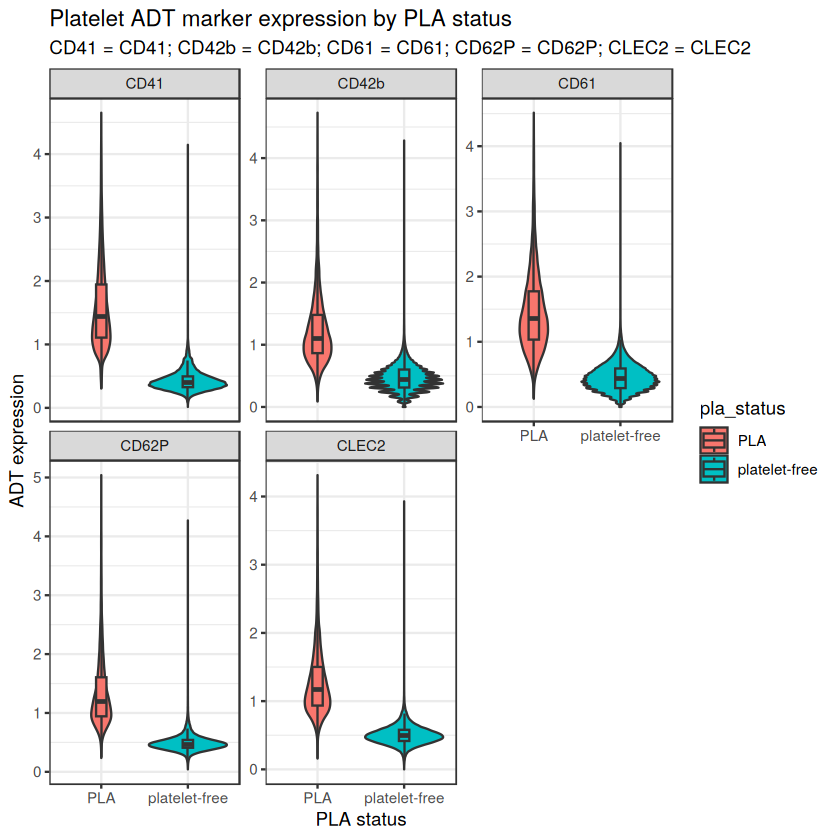

In [7]:
p_marker_status <- adt_long %>%
  dplyr::filter(!is.na(pla_status)) %>%
  ggplot(aes(x = pla_status, y = expression, fill = pla_status)) +
  geom_violin(trim = TRUE) +
  geom_boxplot(width = 0.12, outlier.shape = NA) +
  facet_wrap(~ marker_label, scales = "free_y") +
  theme_bw() +
  labs(
    title = "Platelet ADT marker expression by PLA status",
    subtitle = paste(
      paste0(platelet_marker_map$marker_label, " = ", platelet_marker_map$adt_feature),
      collapse = "; "
    ),
    x = "PLA status",
    y = "ADT expression"
  )

print(p_marker_status)

ggsave(
  file.path(OUT_DIR, "08_ADT_platelet_markers_by_PLA_status.png"),
  p_marker_status,
  width = 9,
  height = 5,
  dpi = 300
)

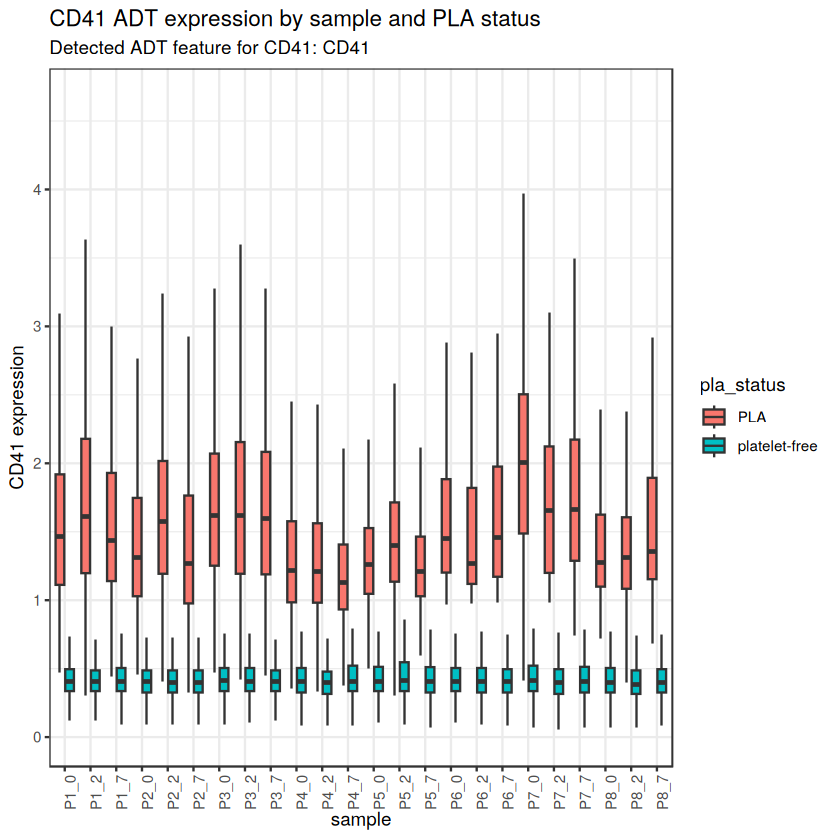

In [9]:
p_cd41_donor <- adt_long %>%
  filter(marker_label == "CD41", !is.na(pla_status)) %>%
  ggplot(aes(x = group_id, y = expression, fill = pla_status)) +
  geom_boxplot(outlier.shape = NA) +
  theme_bw() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1)) +
  labs(
    title = paste0(
      "CD41 ADT expression by ",
      group_col,
      " and PLA status"
    ),
    subtitle = paste0(
      "Detected ADT feature for CD41: ",
      platelet_marker_map$adt_feature[platelet_marker_map$marker_label == "CD41"]
    ),
    x = group_col,
    y = "CD41 expression"
  )

print(p_cd41_donor)

ggsave(
  file.path(OUT_DIR, "09_CD41_by_sample_or_donor_and_PLA_status.png"),
  p_cd41_donor,
  width = 11,
  height = 5,
  dpi = 300
)

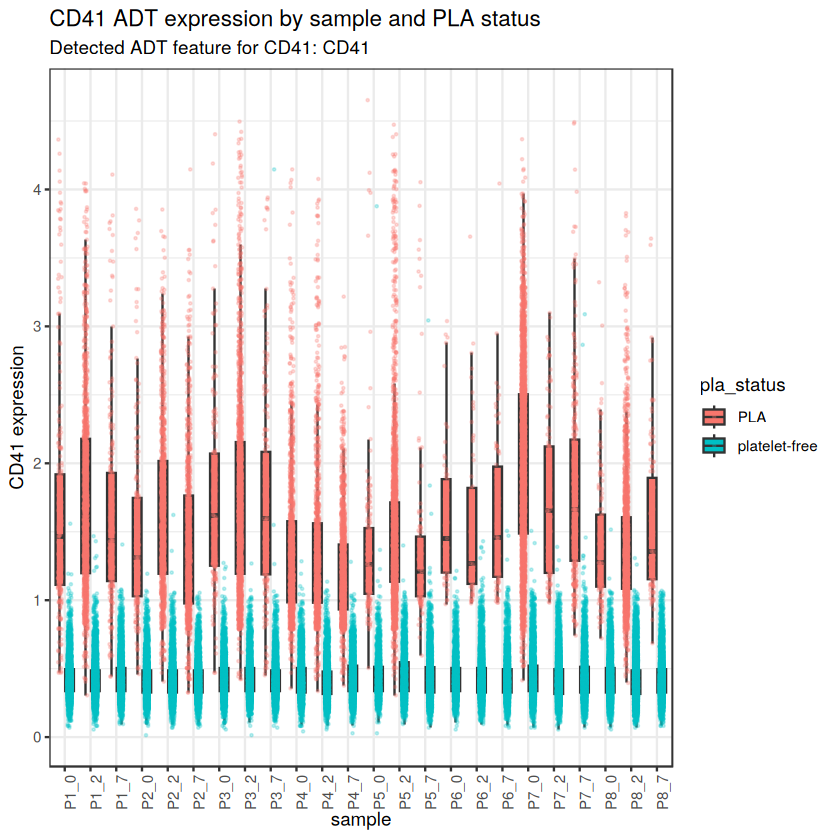

In [10]:
p_cd41_donor <- adt_long %>%
  filter(marker_label == "CD41", !is.na(pla_status)) %>%
  ggplot(aes(x = group_id, y = expression, fill = pla_status)) +
  geom_boxplot(outlier.shape = NA) +
  geom_point(
    aes(color = pla_status),
    position = position_jitterdodge(
      jitter.width = 0.15,
      dodge.width = 0.75
    ),
    size = 0.25,
    alpha = 0.25
  ) +
  theme_bw() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1)) +
  labs(
    title = paste0("CD41 ADT expression by ", group_col, " and PLA status"),
    subtitle = paste0(
      "Detected ADT feature for CD41: ",
      platelet_marker_map$adt_feature[platelet_marker_map$marker_label == "CD41"]
    ),
    x = group_col,
    y = "CD41 expression"
  )


print(p_cd41_donor)

ggsave(
  file.path(OUT_DIR, "09_CD41_by_sample_or_donor_and_PLA_status_detailed.png"),
  p_cd41_donor,
  width = 11,
  height = 5,
  dpi = 300
)

In [11]:
adt_long %>%
  filter(marker_label == "CD41", !is.na(pla_status)) %>%
  group_by(pla_status) %>%
  summarise(
    n = n(),
    min = min(expression, na.rm = TRUE),
    median = median(expression, na.rm = TRUE),
    q75 = quantile(expression, 0.75, na.rm = TRUE),
    q90 = quantile(expression, 0.90, na.rm = TRUE),
    q95 = quantile(expression, 0.95, na.rm = TRUE),
    q99 = quantile(expression, 0.99, na.rm = TRUE),
    max = max(expression, na.rm = TRUE),
    .groups = "drop"
  )

pla_status,n,min,median,q75,q90,q95,q99,max
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
PLA,18825,0.30507921,1.434209,1.9449247,2.5264975,2.922074,3.686655,4.652277
platelet-free,89646,0.01416845,0.405082,0.4959871,0.6337668,0.727644,0.909873,4.146302


In [12]:
cd41_stats <- adt_long %>%
  filter(marker_label == "CD41", !is.na(pla_status)) %>%
  summarise(
    pla_median = median(expression[pla_status == "PLA"], na.rm = TRUE),
    pf_above_pla_median = mean(
      expression[pla_status == "platelet-free"] >= pla_median,
      na.rm = TRUE
    )
  )

print(cd41_stats)

# A tibble: 1 × 2
  pla_median pf_above_pla_median
       <dbl>               <dbl>
1       1.43            0.000178


In [13]:
cd41_thresholds <- adt_long %>%
  filter(marker_label == "CD41", !is.na(pla_status)) %>%
  summarise(
    pla_q25 = quantile(expression[pla_status == "PLA"], 0.25, na.rm = TRUE),
    pla_median = median(expression[pla_status == "PLA"], na.rm = TRUE),
    pla_q75 = quantile(expression[pla_status == "PLA"], 0.75, na.rm = TRUE)
  )

print(cd41_thresholds)

# A tibble: 1 × 3
  pla_q25 pla_median pla_q75
    <dbl>      <dbl>   <dbl>
1    1.11       1.43    1.94


In [14]:
pla_q25 <- cd41_thresholds$pla_q25

adt_long %>%
  filter(marker_label == "CD41", pla_status == "platelet-free") %>%
  summarise(
    n_platelet_free = n(),
    n_pf_above_pla_q25 = sum(expression >= pla_q25, na.rm = TRUE),
    frac_pf_above_pla_q25 = mean(expression >= pla_q25, na.rm = TRUE)
  )

n_platelet_free,n_pf_above_pla_q25,frac_pf_above_pla_q25
<int>,<int>,<dbl>
89646,80,0.000892399


In [16]:
head(adt_long)

cell_id,group_id,pla_status,lineage,adt_feature,expression,marker_label
<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>
L1_AAACCCAAGAAACTCA,P2_7,PLA,Monocytes,CD41,1.0786220,CD41
L1_AAACCCAAGAAACTCA,P2_7,PLA,Monocytes,CD42b,0.9030335,CD42b
L1_AAACCCAAGAAACTCA,P2_7,PLA,Monocytes,CD61,1.3034087,CD61
L1_AAACCCAAGAAACTCA,P2_7,PLA,Monocytes,CD62P,0.7959439,CD62P
L1_AAACCCAAGAAACTCA,P2_7,PLA,Monocytes,CLEC2,0.8652662,CLEC2
L1_AAACCCAAGACATACA,P1_7,platelet-free,CD4 T cells,CD41,0.4515672,CD41


In [19]:
marker_qc_stats <- adt_long %>%
  filter(!is.na(pla_status), !is.na(marker_label)) %>%
  group_by(marker_label) %>%
  summarise(
    n_PLA = sum(pla_status == "PLA"),
    n_platelet_free = sum(pla_status == "platelet-free"),
    pla_q25 = quantile(expression[pla_status == "PLA"], 0.25, na.rm = TRUE),
    pla_median = median(expression[pla_status == "PLA"], na.rm = TRUE),
    pla_q75 = quantile(expression[pla_status == "PLA"], 0.75, na.rm = TRUE),
    platelet_free_median = median(expression[pla_status == "platelet-free"], na.rm = TRUE),
    platelet_free_q95 = quantile(expression[pla_status == "platelet-free"], 0.95, na.rm = TRUE),
    platelet_free_above_pla_q25 = mean(
      expression[pla_status == "platelet-free"] >= pla_q25,
      na.rm = TRUE
    ),
    platelet_free_above_pla_median = mean(
      expression[pla_status == "platelet-free"] >= pla_median,
      na.rm = TRUE
    ),
    .groups = "drop"
  ) %>%
  arrange(marker_label)

print(marker_qc_stats, n = Inf, width = Inf)

write.csv(
  marker_qc_stats,
  file.path(OUT_DIR, "10_platelet_marker_qc_stats.csv"),
  row.names = FALSE
)

# A tibble: 5 × 10
  marker_label n_PLA n_platelet_free pla_q25 pla_median pla_q75
  <chr>        <int>           <int>   <dbl>      <dbl>   <dbl>
1 CD41         18825           89646   1.11        1.43    1.94
2 CD42b        18825           89646   0.865       1.10    1.48
3 CD61         18825           89646   1.03        1.36    1.77
4 CD62P        18825           89646   0.943       1.19    1.61
5 CLEC2        18825           89646   0.935       1.17    1.50
  platelet_free_median platelet_free_q95 platelet_free_above_pla_q25
                 <dbl>             <dbl>                       <dbl>
1                0.405             0.728                    0.000892
2                0.438             0.785                    0.0332  
3                0.429             0.821                    0.0106  
4                0.470             0.707                    0.00530 
5                0.494             0.733                    0.00493 
  platelet_free_above_pla_median
                 

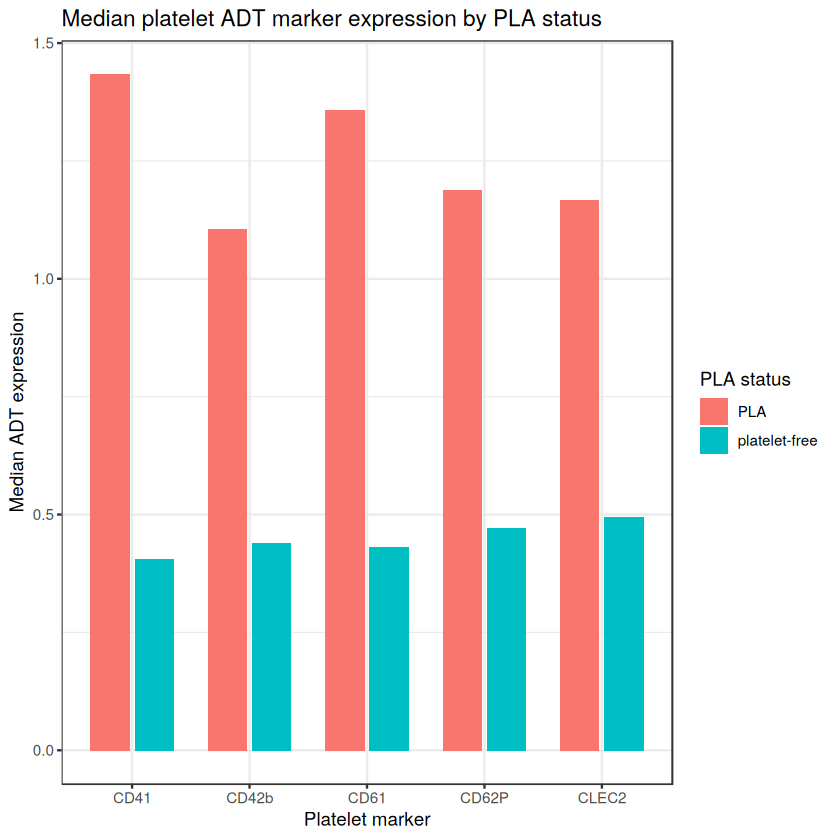

In [20]:
marker_median_plot_df <- marker_qc_stats %>%
  dplyr::select(marker_label, pla_median, platelet_free_median) %>%
  tidyr::pivot_longer(
    cols = c(pla_median, platelet_free_median),
    names_to = "status",
    values_to = "median_expression"
  ) %>%
  dplyr::mutate(
    status = dplyr::recode(
      status,
      pla_median = "PLA",
      platelet_free_median = "platelet-free"
    )
  )

p_marker_medians <- ggplot(
  marker_median_plot_df,
  aes(x = marker_label, y = median_expression, fill = status)
) +
  geom_col(position = position_dodge(width = 0.75), width = 0.65) +
  theme_bw() +
  labs(
    title = "Median platelet ADT marker expression by PLA status",
    x = "Platelet marker",
    y = "Median ADT expression",
    fill = "PLA status"
  )

print(p_marker_medians)

ggsave(
  file.path(OUT_DIR, "10_marker_median_expression_by_PLA_status.png"),
  p_marker_medians,
  width = 7,
  height = 4.5,
  dpi = 300
)

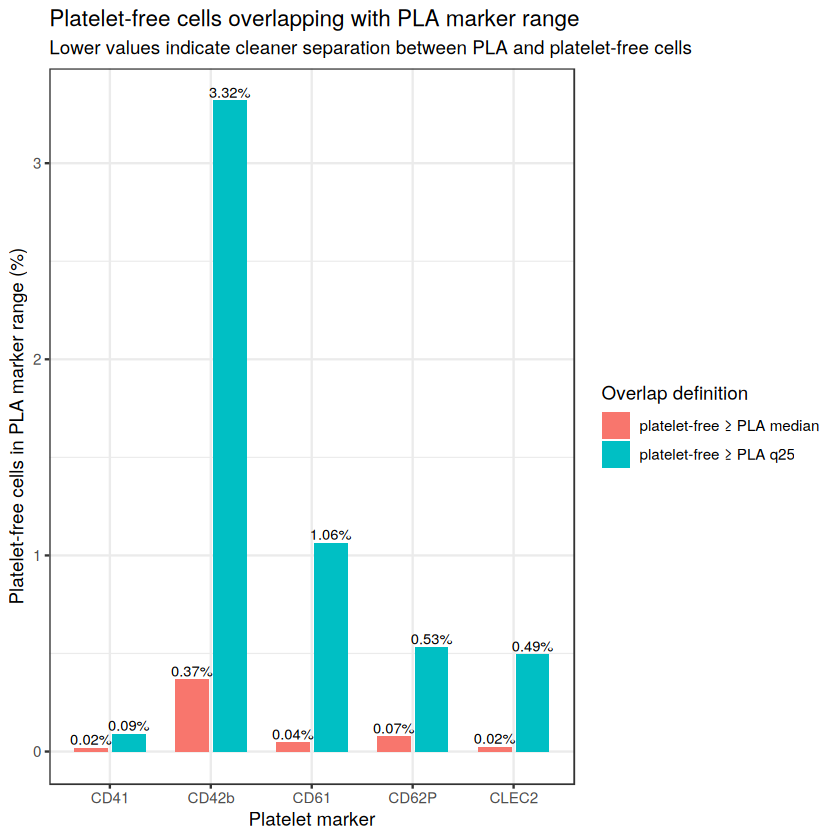

In [21]:
marker_overlap_plot_df <- marker_qc_stats %>%
  dplyr::select(
    marker_label,
    platelet_free_above_pla_q25,
    platelet_free_above_pla_median
  ) %>%
  tidyr::pivot_longer(
    cols = c(platelet_free_above_pla_q25, platelet_free_above_pla_median),
    names_to = "overlap_metric",
    values_to = "fraction"
  ) %>%
  dplyr::mutate(
    overlap_metric = dplyr::recode(
      overlap_metric,
      platelet_free_above_pla_q25 = "platelet-free ≥ PLA q25",
      platelet_free_above_pla_median = "platelet-free ≥ PLA median"
    ),
    percent = fraction * 100
  )

p_marker_overlap <- ggplot(
  marker_overlap_plot_df,
  aes(x = marker_label, y = percent, fill = overlap_metric)
) +
  geom_col(position = position_dodge(width = 0.75), width = 0.65) +
  geom_text(
    aes(label = paste0(round(percent, 2), "%")),
    position = position_dodge(width = 0.75),
    vjust = -0.3,
    size = 3
  ) +
  theme_bw() +
  labs(
    title = "Platelet-free cells overlapping with PLA marker range",
    subtitle = "Lower values indicate cleaner separation between PLA and platelet-free cells",
    x = "Platelet marker",
    y = "Platelet-free cells in PLA marker range (%)",
    fill = "Overlap definition"
  )

print(p_marker_overlap)

ggsave(
  file.path(OUT_DIR, "11_platelet_free_overlap_with_PLA_marker_range.png"),
  p_marker_overlap,
  width = 8,
  height = 4.8,
  dpi = 300
)

In [22]:
sample_marker_qc <- adt_long %>%
  filter(!is.na(pla_status), !is.na(marker_label)) %>%
  group_by(group_id, marker_label) %>%
  summarise(
    n_PLA = sum(pla_status == "PLA"),
    n_platelet_free = sum(pla_status == "platelet-free"),
    pla_median = median(expression[pla_status == "PLA"], na.rm = TRUE),
    platelet_free_median = median(expression[pla_status == "platelet-free"], na.rm = TRUE),
    median_difference = pla_median - platelet_free_median,
    platelet_free_q95 = quantile(expression[pla_status == "platelet-free"], 0.95, na.rm = TRUE),
    pla_q25 = quantile(expression[pla_status == "PLA"], 0.25, na.rm = TRUE),
    platelet_free_above_pla_q25 = mean(
      expression[pla_status == "platelet-free"] >= pla_q25,
      na.rm = TRUE
    ),
    .groups = "drop"
  ) %>%
  arrange(marker_label, median_difference)

print(sample_marker_qc, n = Inf, width = Inf)

write.csv(
  sample_marker_qc,
  file.path(OUT_DIR, "12_platelet_marker_qc_by_sample.csv"),
  row.names = FALSE
)

# A tibble: 120 × 10
    group_id marker_label n_PLA n_platelet_free pla_median platelet_free_median
    <chr>    <chr>        <int>           <int>      <dbl>                <dbl>
  1 P4_7     CD41          1530            3728      1.13                 0.405
  2 P5_7     CD41           117            3490      1.21                 0.405
  3 P4_0     CD41          1267            3326      1.21                 0.405
  4 P4_2     CD41          1082            4217      1.21                 0.396
  5 P5_0     CD41           167            1934      1.26                 0.405
  6 P6_2     CD41            68            4557      1.27                 0.405
  7 P2_7     CD41           879            3787      1.27                 0.396
  8 P8_0     CD41           138            4781      1.27                 0.396
  9 P2_0     CD41           205            3707      1.32                 0.405
 10 P8_2     CD41          1969            5925      1.31                 0.386
 11 P8_7     CD41  

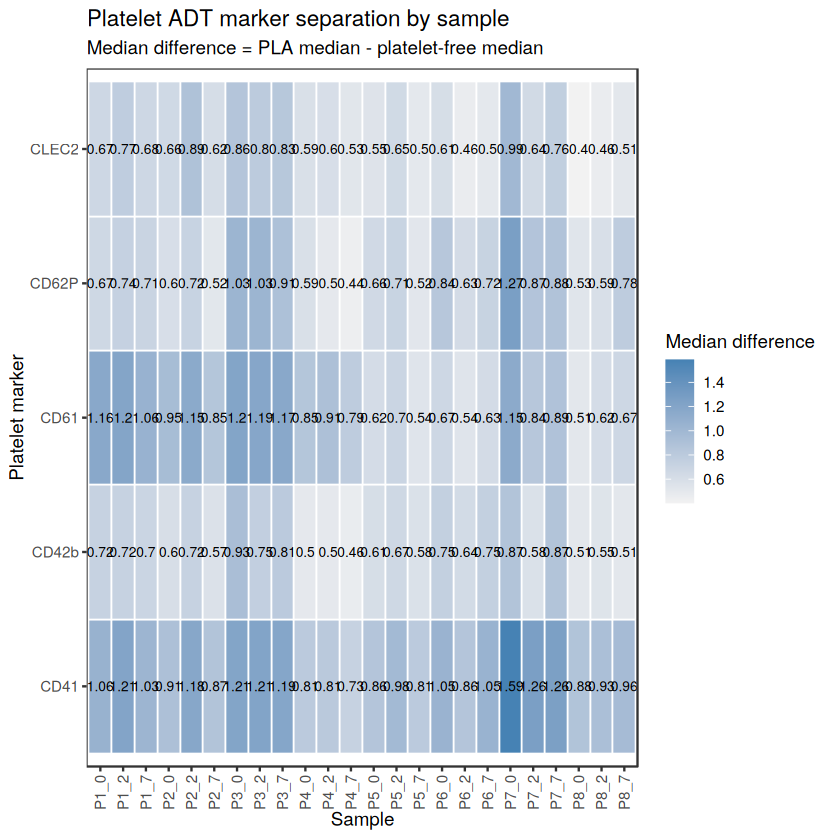

In [23]:
sample_marker_qc_plot <- sample_marker_qc %>%
  mutate(
    overlap_percent = platelet_free_above_pla_q25 * 100
  )

p_sample_median_diff <- ggplot(
  sample_marker_qc_plot,
  aes(x = group_id, y = marker_label, fill = median_difference)
) +
  geom_tile(color = "white", linewidth = 0.35) +
  geom_text(aes(label = round(median_difference, 2)), size = 2.8) +
  scale_fill_gradient(
    low = "grey95",
    high = "steelblue",
    na.value = "grey80"
  ) +
  theme_bw() +
  theme(
    panel.grid = element_blank(),
    axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5)
  ) +
  labs(
    title = "Platelet ADT marker separation by sample",
    subtitle = "Median difference = PLA median - platelet-free median",
    x = "Sample",
    y = "Platelet marker",
    fill = "Median difference"
  )

print(p_sample_median_diff)

ggsave(
  file.path(OUT_DIR, "13_sample_marker_median_difference_heatmap.png"),
  p_sample_median_diff,
  width = max(8, length(unique(sample_marker_qc_plot$group_id)) * 0.35),
  height = 4.5,
  dpi = 300
)

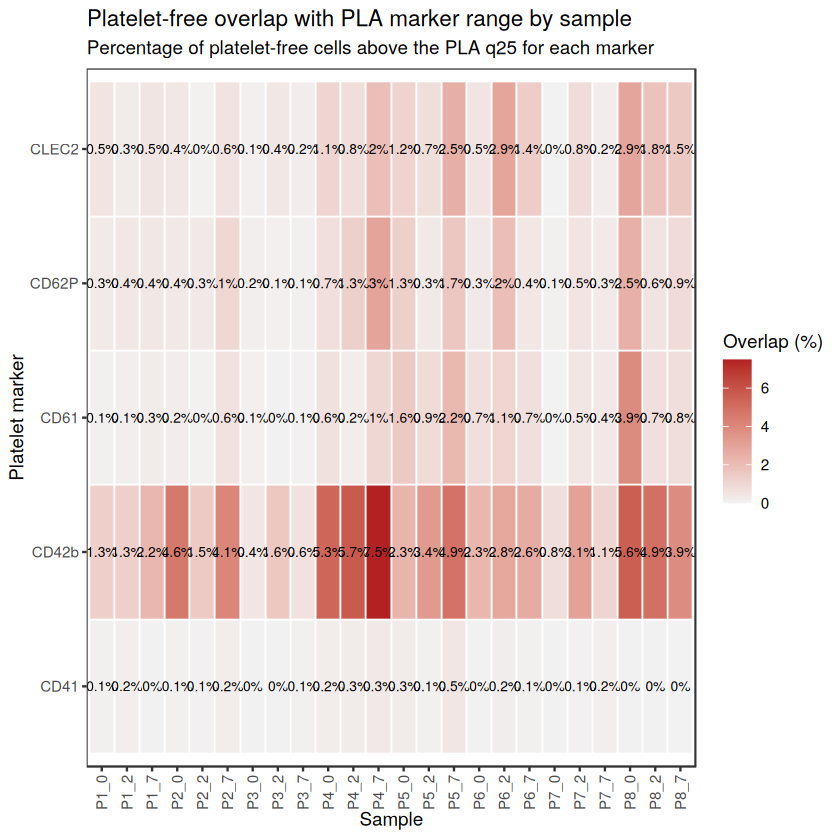

In [24]:
p_sample_overlap <- ggplot(
  sample_marker_qc_plot,
  aes(x = group_id, y = marker_label, fill = overlap_percent)
) +
  geom_tile(color = "white", linewidth = 0.35) +
  geom_text(aes(label = paste0(round(overlap_percent, 1), "%")), size = 2.8) +
  scale_fill_gradient(
    low = "grey95",
    high = "firebrick",
    na.value = "grey80"
  ) +
  theme_bw() +
  theme(
    panel.grid = element_blank(),
    axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5)
  ) +
  labs(
    title = "Platelet-free overlap with PLA marker range by sample",
    subtitle = "Percentage of platelet-free cells above the PLA q25 for each marker",
    x = "Sample",
    y = "Platelet marker",
    fill = "Overlap (%)"
  )

print(p_sample_overlap)

ggsave(
  file.path(OUT_DIR, "14_sample_platelet_free_overlap_heatmap.png"),
  p_sample_overlap,
  width = max(8, length(unique(sample_marker_qc_plot$group_id)) * 0.35),
  height = 4.5,
  dpi = 300
)

In [25]:
sample_marker_qc %>%
  filter(
    median_difference < 0.3 |
      platelet_free_above_pla_q25 > 0.10
  ) %>%
  arrange(marker_label, median_difference) %>%
  print(n = Inf, width = Inf)

# A tibble: 0 × 10
# ℹ 10 variables: group_id <chr>, marker_label <chr>, n_PLA <int>, n_platelet_free <int>, pla_median <dbl>, platelet_free_median <dbl>, median_difference <dbl>, platelet_free_q95 <dbl>, pla_q25 <dbl>, platelet_free_above_pla_q25 <dbl>


In [26]:
lineage_marker_qc <- adt_long %>%
  filter(!is.na(pla_status), !is.na(marker_label), !is.na(lineage)) %>%
  group_by(lineage, marker_label) %>%
  summarise(
    n_PLA = sum(pla_status == "PLA"),
    n_platelet_free = sum(pla_status == "platelet-free"),
    pla_median = median(expression[pla_status == "PLA"], na.rm = TRUE),
    platelet_free_median = median(expression[pla_status == "platelet-free"], na.rm = TRUE),
    median_difference = pla_median - platelet_free_median,
    platelet_free_above_pla_q25 = mean(
      expression[pla_status == "platelet-free"] >= quantile(expression[pla_status == "PLA"], 0.25, na.rm = TRUE),
      na.rm = TRUE
    ),
    .groups = "drop"
  ) %>%
  arrange(lineage, marker_label)

print(lineage_marker_qc, n = Inf, width = Inf)

write.csv(
  lineage_marker_qc,
  file.path(OUT_DIR, "13_platelet_marker_qc_by_lineage.csv"),
  row.names = FALSE
)

# A tibble: 30 × 8
   lineage     marker_label n_PLA n_platelet_free pla_median
   <chr>       <chr>        <int>           <int>      <dbl>
 1 B cells     CD41           101           10058      1.17 
 2 B cells     CD42b          101           10058      1.04 
 3 B cells     CD61           101           10058      0.821
 4 B cells     CD62P          101           10058      0.841
 5 B cells     CLEC2          101           10058      0.865
 6 CD4 T cells CD41           159           38946      1.24 
 7 CD4 T cells CD42b          159           38946      0.975
 8 CD4 T cells CD61           159           38946      0.906
 9 CD4 T cells CD62P          159           38946      0.992
10 CD4 T cells CLEC2          159           38946      0.916
11 CD8 T cells CD41           164           21594      1.21 
12 CD8 T cells CD42b          164           21594      0.957
13 CD8 T cells CD61           164           21594      0.906
14 CD8 T cells CD62P          164           21594      0.948
15 CD

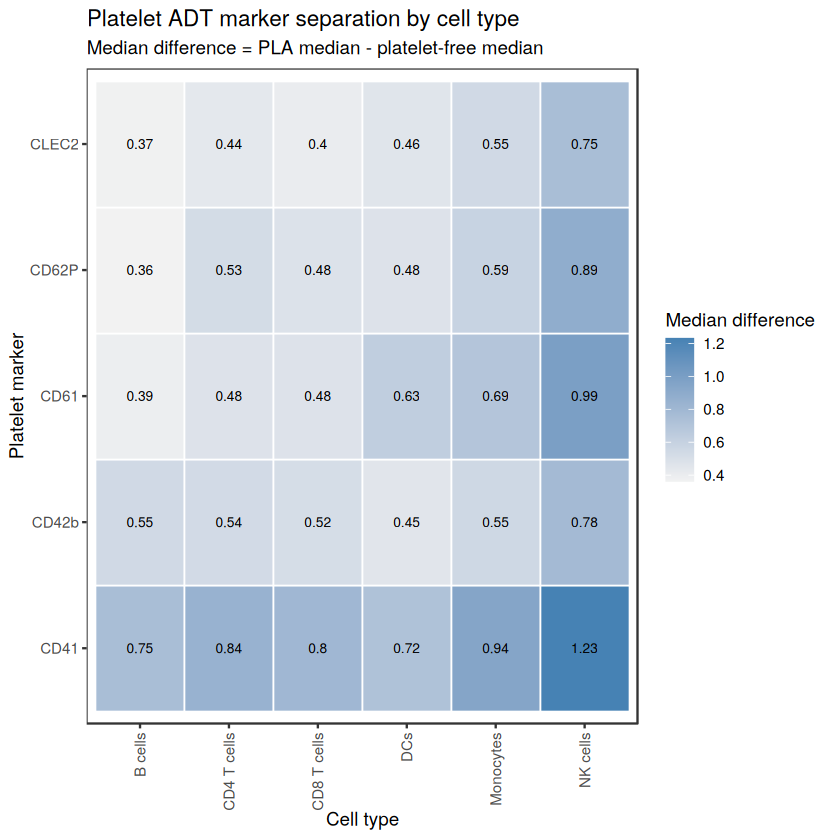

In [27]:
lineage_marker_qc_plot <- lineage_marker_qc %>%
  mutate(
    overlap_percent = platelet_free_above_pla_q25 * 100
  )

p_lineage_median_diff <- ggplot(
  lineage_marker_qc_plot,
  aes(x = lineage, y = marker_label, fill = median_difference)
) +
  geom_tile(color = "white", linewidth = 0.35) +
  geom_text(aes(label = round(median_difference, 2)), size = 2.8) +
  scale_fill_gradient(
    low = "grey95",
    high = "steelblue",
    na.value = "grey80"
  ) +
  theme_bw() +
  theme(
    panel.grid = element_blank(),
    axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5)
  ) +
  labs(
    title = "Platelet ADT marker separation by cell type",
    subtitle = "Median difference = PLA median - platelet-free median",
    x = "Cell type",
    y = "Platelet marker",
    fill = "Median difference"
  )

print(p_lineage_median_diff)

ggsave(
  file.path(OUT_DIR, "15_lineage_marker_median_difference_heatmap.png"),
  p_lineage_median_diff,
  width = max(8, length(unique(lineage_marker_qc_plot$lineage)) * 0.5),
  height = 4.5,
  dpi = 300
)

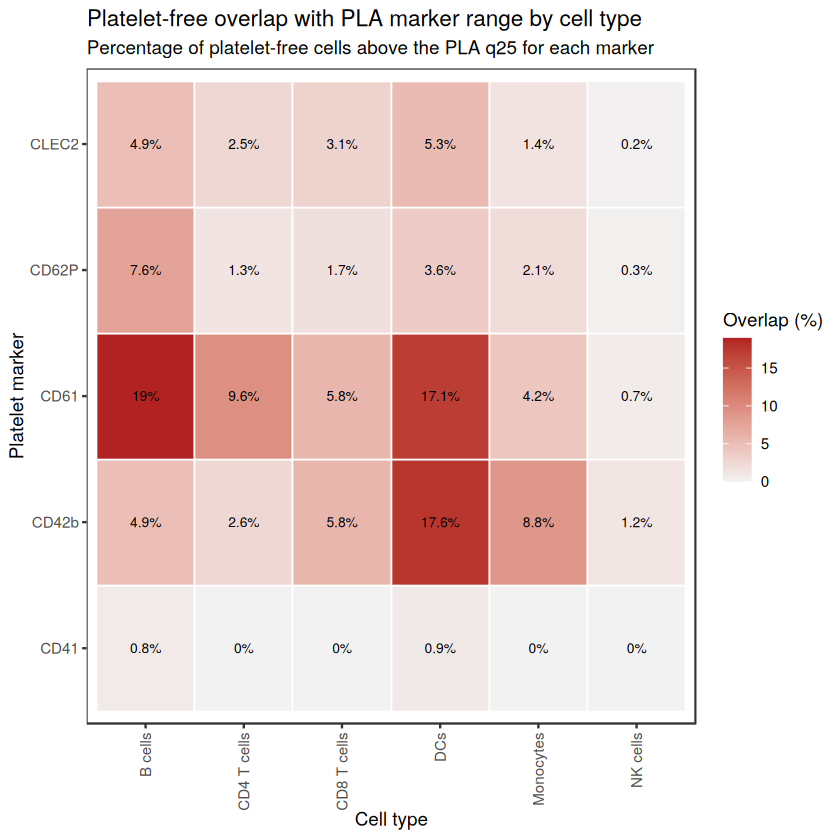

In [28]:
p_lineage_overlap <- ggplot(
  lineage_marker_qc_plot,
  aes(x = lineage, y = marker_label, fill = overlap_percent)
) +
  geom_tile(color = "white", linewidth = 0.35) +
  geom_text(aes(label = paste0(round(overlap_percent, 1), "%")), size = 2.8) +
  scale_fill_gradient(
    low = "grey95",
    high = "firebrick",
    na.value = "grey80"
  ) +
  theme_bw() +
  theme(
    panel.grid = element_blank(),
    axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5)
  ) +
  labs(
    title = "Platelet-free overlap with PLA marker range by cell type",
    subtitle = "Percentage of platelet-free cells above the PLA q25 for each marker",
    x = "Cell type",
    y = "Platelet marker",
    fill = "Overlap (%)"
  )

print(p_lineage_overlap)

ggsave(
  file.path(OUT_DIR, "16_lineage_platelet_free_overlap_heatmap.png"),
  p_lineage_overlap,
  width = max(8, length(unique(lineage_marker_qc_plot$lineage)) * 0.5),
  height = 4.5,
  dpi = 300
)

In [30]:
head(sample_marker_qc)

group_id,marker_label,n_PLA,n_platelet_free,pla_median,platelet_free_median,median_difference,platelet_free_q95,pla_q25,platelet_free_above_pla_q25
<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
P4_7,CD41,1530,3728,1.130623,0.4050820,0.7255414,0.7276440,0.9325909,0.003487124
P5_7,CD41,117,3490,1.210283,0.4050820,0.8052011,0.7548416,1.0288804,0.004584527
P4_0,CD41,1267,3326,1.214528,0.4050820,0.8094460,0.7345130,0.9845597,0.002405292
P4_2,CD41,1082,4217,1.210283,0.3955199,0.8147632,0.6854081,0.9818942,0.002608489
P5_0,CD41,167,1934,1.264108,0.4050820,0.8590264,0.7413353,1.0465697,0.002585315
P6_2,CD41,68,4557,1.266120,0.4050820,0.8610378,0.7413353,1.1190319,0.001755541


# QC

In [32]:
min_marker_median_diff <- 0.3
max_pf_overlap <- 0.10
min_passing_markers <- 1

sample_adt_qc <- sample_marker_qc %>%
  mutate(
    marker_pass = median_difference >= min_marker_median_diff &
      platelet_free_above_pla_q25 <= max_pf_overlap
  ) %>%
  group_by(group_id) %>%
  summarise(
    n_markers_tested = n(),
    n_markers_pass = sum(marker_pass, na.rm = TRUE),
    mean_median_difference = mean(median_difference, na.rm = TRUE),
    max_pf_overlap = max(platelet_free_above_pla_q25, na.rm = TRUE),
    sample_adt_status = case_when(
      n_markers_pass >= min_passing_markers ~ "ADT_ok",
      TRUE ~ "ADT_suspicious"
    ),
    .groups = "drop"
  )

print(sample_adt_qc, n = Inf, width = Inf)

write.csv(
  sample_adt_qc,
  file.path(OUT_DIR, "17_sample_ADT_QC_status.csv"),
  row.names = FALSE
)

# A tibble: 24 × 6
   group_id n_markers_tested n_markers_pass mean_median_difference
   <chr>               <int>          <int>                  <dbl>
 1 P1_0                    5              5                  0.858
 2 P1_2                    5              5                  0.928
 3 P1_7                    5              5                  0.834
 4 P2_0                    5              5                  0.744
 5 P2_2                    5              5                  0.933
 6 P2_7                    5              5                  0.687
 7 P3_0                    5              5                  1.05 
 8 P3_2                    5              5                  0.997
 9 P3_7                    5              5                  0.982
10 P4_0                    5              5                  0.668
11 P4_2                    5              5                  0.665
12 P4_7                    5              5                  0.589
13 P5_0                    5              5

In [33]:
lineage_adt_qc <- lineage_marker_qc %>%
  mutate(
    marker_pass = median_difference >= min_marker_median_diff &
      platelet_free_above_pla_q25 <= max_pf_overlap
  ) %>%
  group_by(lineage) %>%
  summarise(
    n_markers_tested = n(),
    n_markers_pass = sum(marker_pass, na.rm = TRUE),
    mean_median_difference = mean(median_difference, na.rm = TRUE),
    max_pf_overlap = max(platelet_free_above_pla_q25, na.rm = TRUE),
    lineage_adt_status = case_when(
      n_markers_pass >= min_passing_markers ~ "ADT_ok",
      TRUE ~ "ADT_suspicious"
    ),
    .groups = "drop"
  )

print(lineage_adt_qc, n = Inf, width = Inf)

write.csv(
  lineage_adt_qc,
  file.path(OUT_DIR, "18_lineage_ADT_QC_status.csv"),
  row.names = FALSE
)

# A tibble: 6 × 6
  lineage     n_markers_tested n_markers_pass mean_median_difference
  <chr>                  <int>          <int>                  <dbl>
1 B cells                    5              4                  0.484
2 CD4 T cells                5              5                  0.564
3 CD8 T cells                5              5                  0.536
4 DCs                        5              3                  0.549
5 Monocytes                  5              5                  0.666
6 NK cells                   5              5                  0.929
  max_pf_overlap lineage_adt_status
           <dbl> <chr>             
1         0.190  ADT_ok            
2         0.0956 ADT_ok            
3         0.0582 ADT_ok            
4         0.176  ADT_ok            
5         0.0877 ADT_ok            
6         0.0117 ADT_ok            


In [43]:
summary_table <- readRDS(file.path(OUT_DIR, "sample_celltype_frequency_QC_table.rds"))

trusted_pair_table <- summary_table %>%
  dplyr::left_join(
    sample_adt_qc,
    by = c("sample_id" = "group_id")
  ) %>%
  dplyr::left_join(
    lineage_adt_qc,
    by = c("celltype_id" = "lineage")
  ) %>%
  dplyr::mutate(
    extreme_high_PLA = freq_PLA >= 0.90,

    trusted_pair = usable_celltype_sample &
      sample_adt_status == "ADT_ok" &
      lineage_adt_status == "ADT_ok",

    final_pair_status = dplyr::case_when(
      !usable_celltype_sample ~ "frequency_QC_fail",
      is.na(sample_adt_status) ~ "sample_ADT_missing",
      is.na(lineage_adt_status) ~ "lineage_ADT_missing",
      sample_adt_status == "ADT_suspicious" ~ "sample_ADT_suspicious",
      lineage_adt_status == "ADT_suspicious" ~ "lineage_ADT_suspicious",
      trusted_pair & extreme_high_PLA ~ "trusted_but_extreme_PLA",
      trusted_pair ~ "trusted",
      TRUE ~ "review"
    )
  )

print(
  trusted_pair_table %>%
    dplyr::count(final_pair_status),
  n = Inf
)

write.csv(
  trusted_pair_table,
  file.path(OUT_DIR, "19_final_sample_lineage_QC_table.csv"),
  row.names = FALSE
)

saveRDS(
  trusted_pair_table,
  file.path(OUT_DIR, "19_final_sample_lineage_QC_table.rds")
)

# A tibble: 3 × 2
  final_pair_status           n
  <chr>                   <int>
1 frequency_QC_fail          41
2 trusted                   116
3 trusted_but_extreme_PLA    10
